# Import and load

In [118]:
# Provides support for numerical computations and multi-dimensional arrays.
import numpy as np  
# Offers powerful data manipulation and analysis tools using DataFrames.
import pandas as pd 
# Provides tools for creating and manipulating data structures. 
import re
# Enables creation of static, interactive, and animated visualizations in Python.
import matplotlib.pyplot as plt  
# Allows custom colormap creation for matplotlib plots.
from matplotlib.colors import LinearSegmentedColormap  
# Simplifies statistical data visualization and integrates seamlessly with matplotlib.
import seaborn as sns  
# Facilitates creation of interactive visualizations and dashboards using Plotly.
import plotly.graph_objects as go  
# Offers high-level interface for creating interactive Plotly visualizations quickly.
import plotly.express as px  
# Provides tools for arranging multiple subplots in Plotly visualizations.
import plotly.subplots as sp  
# Simplifies the creation of complex subplot layouts.
from plotly.subplots import make_subplots  
# Enables detailed control of individual Plotly plot objects.
import plotly.graph_objs as go  
# Tools for encoding categorical variables.
from sklearn.preprocessing import LabelEncoder, MultiLabelBinarizer  
# Provides scaling tools for normalizing features.
from sklearn.preprocessing import MinMaxScaler, StandardScaler  
# Function to compute mean absolute error for model evaluation.
from sklearn.metrics import mean_absolute_error  
# Performs Principal Component Analysis for dimensionality reduction.
from sklearn.decomposition import PCA  
# Offers utilities for generating random numbers and sequences.
import random  
# Provides functions for calculating statistical measures (mean, median, etc.).
import statistics

In [119]:
data_train = pd.read_csv("data/train.csv", na_values="\\N")
data_test = pd.read_csv("data/test.csv", na_values="\\N")

print("Datasets loaded successfully.")

Datasets loaded successfully.


# Data description and manipulation summary

| **Feature**                   | **Description**                                                                                 | **Data Type**  | **Nullability** | **Cast/Re-elaboration Needed**    |
|-------------------------------|-------------------------------------------------------------------------------------------------|----------------|-----------------|----------------------------------|
| **originalTitle**             | Original title, in the original language.                                                      | String         | Non-Null        | Cast all to lowecase strings with no special character     |
| **runtimeMinutes**            | Primary runtime of the title, in minutes.                                                     | Integer        | -               | -1 if NA                          |
| **isAdult**                   | Whether or not the title is for adults (0: non-adult; 1: adult).                              | Boolean        | -               | Bool                              |
| **startYear**                 | Release year of a title; for TV Series, the series start year.                                | Integer        | -               | -                                 |
| **endYear**                   | TV Series end year.                                                                           | Integer        | -               | -1 if NA                          |
| **numVotes**                  | Number of votes the title has received.                                                       | Integer        | -               | -                                 |
| **numRegions**                | Number of regions for this version of the title.                                              | Integer        | -               | -                                 |
| **worstRating**               | Worst title rating.                                                                           | Integer        | -               | -                                 |
| **bestRating**                | Best title rating.                                                                            | Integer        | -               | -                                 |
| **canHaveEpisodes**           | Whether or not the title can have episodes.                                                   | Boolean        | -               | -                                 |
| **isRatable**                 | Whether or not the title can be rated by users.                                               | Boolean        | -               | -                                 |
| **totalImages**               | Total number of images for the title on the IMDb page.                                        | Integer        | -               | -                                 |
| **totalVideos**               | Total number of videos for the title on the IMDb page.                                        | Integer        | -               | -                                 |
| **totalCredits**              | Total number of credits for the title.                                                        | Integer        | -               | -                                 |
| **criticReviewsTotal**        | Total number of critic reviews.                                                               | Integer        | -               | -                                 |
| **awardWins**                 | Number of awards the title won.                                                               | Integer        | -               | -1 if false                       |
| **awardNominationsExcludeWins** | Number of award nominations excluding wins.                                                   | Integer        | -               | -                                 |
| **titleType**                 | Type/format of the title (e.g., movie, short, tvseries, tvepisode, video, etc.).              | String         | -               | Merging                           |
| **rating**                    | IMDb title rating class.                                                                      | Object        | -               | cast to an int mantaining the upper bound                       |
| **ratingCount**               | Total number of user ratings submitted for the title.                                         | Integer        | -               | -                                 |
| **countryOfOrigin**           | Country where the title was primarily produced.                                               | One Hot Encoded | -              | One hot encoding                  |
| **genres**                    | Genre(s) associated with the title (e.g., drama, comedy, action).                            | One Hot Encoded | -              | One hot encoding                  |
| **userReviewsTotal**          | Total number of user reviews.                                                                 | Integer        | -               | -                                 |

In [120]:
# print all the columns with type associated in the dataframe

print(data_train.dtypes)

originalTitle                   object
rating                          object
startYear                        int64
endYear                        float64
runtimeMinutes                 float64
awardWins                      float64
numVotes                         int64
worstRating                      int64
bestRating                       int64
totalImages                      int64
totalVideos                      int64
totalCredits                     int64
criticReviewsTotal               int64
titleType                       object
awardNominationsExcludeWins      int64
canHaveEpisodes                   bool
isRatable                         bool
isAdult                          int64
numRegions                       int64
userReviewsTotal                 int64
ratingCount                      int64
countryOfOrigin                 object
genres                          object
dtype: object


# Missing values analysis
Now we will analyze the missing values in the dataset.

In order to achieve that first of all, analyzing the dataset we see that a missing values in the origina dataset is '\N'.

The following function prints a plot of percentage of missing values of each column of the dataset.
The percentage of the missing values is coloured by his components grouped by "titleType"

/tmp/ipykernel_14686/3161133526.py:32: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped_missing = data.groupby('titleType', group_keys=False).apply(
/tmp/ipykernel_14686/3161133526.py:42: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = plt.cm.get_cmap('viridis', len(grouped_missing.index.get_level_values(0).unique()))
/tmp/ipykernel_14686/3161133526.py:32: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping c

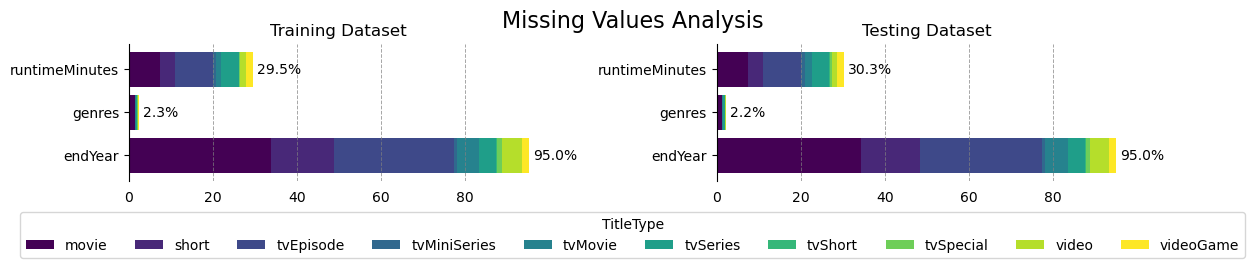

In [121]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

def plot_missing_values_by_title_type_combined(data_train, data_test, global_title, train_title, test_title):
    """
    Plots the percentage of missing values for each column in both datasets (train and test),
    grouped by titleType, with customizable titles for the figure and subplots.

    Args:
        data_train (pd.DataFrame): The training dataset containing various columns including 'titleType'.
        data_test (pd.DataFrame): The testing dataset containing various columns including 'titleType'.
        global_title (str): The global title for the entire figure.
        train_title (str): The title for the training dataset subplot.
        test_title (str): The title for the testing dataset subplot.
    """
    def plot_individual(ax, data, title):
        """
        Helper function to create a plot for an individual dataset.
        """
        # Calculate the overall percentage of missing values for each column
        overall_missing_percentages = data.isna().mean() * 100

        # Remove columns with 0% missing values
        overall_missing_percentages = overall_missing_percentages[overall_missing_percentages > 0]

        # Sort columns alphabetically
        overall_missing_percentages = overall_missing_percentages.sort_index()

        # Calculate the percentage of missing values for each column grouped by titleType
        grouped_missing = data.groupby('titleType', group_keys=False).apply(
            lambda x: x.isna().sum() / len(data) * 100
        )

        # Filter grouped data to keep only columns with missing values
        grouped_missing = grouped_missing[overall_missing_percentages.index]

        left = np.zeros(len(overall_missing_percentages))

        # Get the viridis colormap
        colormap = plt.cm.get_cmap('viridis', len(grouped_missing.index.get_level_values(0).unique()))

        # Alternate background shading for rows
        for i in range(len(overall_missing_percentages)):
            ax.barh(
                y=[i],
                width=0,  # Invisible bar for background
                height=0.9,  # Adjust for full coverage
                color='gray' if i % 2 == 0 else 'white',
                edgecolor='none'
            )

        for i, titleType in enumerate(grouped_missing.index.get_level_values(0).unique()):
            values = grouped_missing.loc[titleType]
            bars = ax.barh(overall_missing_percentages.index, values, left=left, label=titleType, color=colormap(i))
            left += values

        # Add percentage labels to the overall missing values
        for i, (column, percentage) in enumerate(overall_missing_percentages.items()):
            if percentage > 0:  # Only add text if the percentage is greater than 0
                ax.text(
                    overall_missing_percentages[column] + 1,  # Position the text slightly after the bar
                    i,
                    f'{percentage:.1f}%',
                    va='center',
                    ha='left',
                    fontsize=10,
                    color='black'
                )

        # Remove the top, right, and bottom spines
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['bottom'].set_visible(False)

        # Add dashed gridlines for the x-axis numbers
        ax.xaxis.set_ticks_position('none')  # Remove ticks from the x-axis
        ax.grid(axis='x', linestyle='--', color='gray', linewidth=0.7, alpha=0.7)

        # Set subplot-specific title
        ax.set_title(title)

        # Adjust the y-axis tick labels rotation and alignment
        ax.set_yticks(range(len(overall_missing_percentages.index)))
        ax.set_yticklabels(overall_missing_percentages.index, rotation=0, ha='right')

    # Calculate the number of columns with missing values in both datasets
    num_missing_train = (data_train.isna().mean() * 100 > 0).sum()
    num_missing_test = (data_test.isna().mean() * 100 > 0).sum()
    max_missing = max(num_missing_train, num_missing_test)

    # Create a figure with GridSpec layout
    fig = plt.figure(figsize=(13, max_missing*1))  # Increase height to accommodate legend
    gs = GridSpec(4, 2, height_ratios=[0.1, 0.8, 0.1, 0.1], hspace=0.3)  # Add extra row for legend

    # Add the global title
    ax_title = fig.add_subplot(gs[0, :])
    ax_title.text(0.5, 0.5, global_title, fontsize=16, ha='center', va='center')
    ax_title.axis('off')

    # Create subplots for the training and testing data
    ax_train = fig.add_subplot(gs[1, 0])
    ax_test = fig.add_subplot(gs[1, 1], sharey=ax_train)

    # Plot for training data
    plot_individual(ax_train, data_train, train_title)

    # Plot for testing data
    plot_individual(ax_test, data_test, test_title)

    # Add a horizontal legend below the plots
    handles, labels = ax_test.get_legend_handles_labels()
    ax_legend = fig.add_subplot(gs[3, :])
    ax_legend.legend(handles, labels, title='TitleType', loc='center', ncol=len(labels))
    ax_legend.axis('off')

    plt.subplots_adjust(wspace=0.4)  # Increase wspace to add more space between the subplots
    plt.show()

# Crea copie dei dataset senza la colonna 'awardWins'
data_train_no_awardWins = data_train.drop(columns=['awardWins'])
data_test_no_awardWins = data_test.drop(columns=['awardWins'])

# Esempio di utilizzo
plot_missing_values_by_title_type_combined(
    data_train=data_train_no_awardWins,
    data_test=data_test_no_awardWins,
    global_title="Missing Values Analysis",
    train_title="Training Dataset",
    test_title="Testing Dataset"
)


# Most frequent values
Check for each column which is the most frequent value and than print the percentage of this most frequent value in a tablea

In [122]:
import pandas as pd

def most_frequent_values(data_train, data_test):
    """
    Calculate the most frequent values in each column of the training and testing datasets,
    and the percentage of occurrences of these values.

    Args:
        data_train (pd.DataFrame): The training dataset.
        data_test (pd.DataFrame): The testing dataset.

    Returns:
        pd.DataFrame: A DataFrame containing the most frequent values and their percentages in both datasets.
    """
    results = []

    for column in data_train.columns:
        # Calculate the most frequent value in the training dataset
        train_most_frequent = data_train[column].mode()[0]
        train_percent = (data_train[column] == train_most_frequent).mean() * 100

        # Calculate the most frequent value in the testing dataset
        test_most_frequent = data_test[column].mode()[0]
        test_percent = (data_test[column] == test_most_frequent).mean() * 100

        # Append the results to the list
        results.append({
            'Column': column,
            'Most Frequent Value': train_most_frequent,
            'Train %': train_percent,
            'Test Most Frequent Value': test_most_frequent,
            'Test %': test_percent
        })

    # Convert the list of results to a DataFrame
    results_df = pd.DataFrame(results)

    return results_df

# Example usage
results_df = most_frequent_values(data_train, data_test)
print(results_df)

                         Column Most Frequent Value     Train %  \
0                 originalTitle        Episode #1.1    0.206926   
1                        rating              (7, 8]   29.346966   
2                     startYear                2016    2.592660   
3                       endYear              2022.0    0.225184   
4                runtimeMinutes                30.0    3.955937   
5                     awardWins                 0.0   72.856186   
6                      numVotes                   8    3.170836   
7                   worstRating                   1  100.000000   
8                    bestRating                  10  100.000000   
9                   totalImages                   1   30.004260   
10                  totalVideos                   0   90.201448   
11                 totalCredits                   8    1.862333   
12           criticReviewsTotal                   0   69.618404   
13                    titleType               movie   33.68632

# `rating`
The rating column is formatted as `(x, x+1]`, where `x` represents the lower bound, and `x+1` is the upper bound.

To simplify analysis and standardize the data format, the range is converted into a single value by retaining only the upper bound (x+1) as an integer.

In [123]:
data_train['rating'] = data_train['rating'].apply(lambda rt: int(rt.split(',')[1].replace(']', '')))
data_test['rating'] = data_test['rating'].apply(lambda rt: int(rt.split(',')[1].replace(']', '')))

# convert the column to int
data_train['rating'] = data_train['rating'].astype(int)
print("rating cleaned successfully.")

rating cleaned successfully.


#### `startYear` and `endYear`

`endYear` has missing values.
The following code snippet shows the percentage of missing values grouped by `titleType`.

/tmp/ipykernel_14686/2844931383.py:21: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped_missing = data.groupby('titleType').apply(
/tmp/ipykernel_14686/2844931383.py:21: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped_missing = data.groupby('titleType').apply(


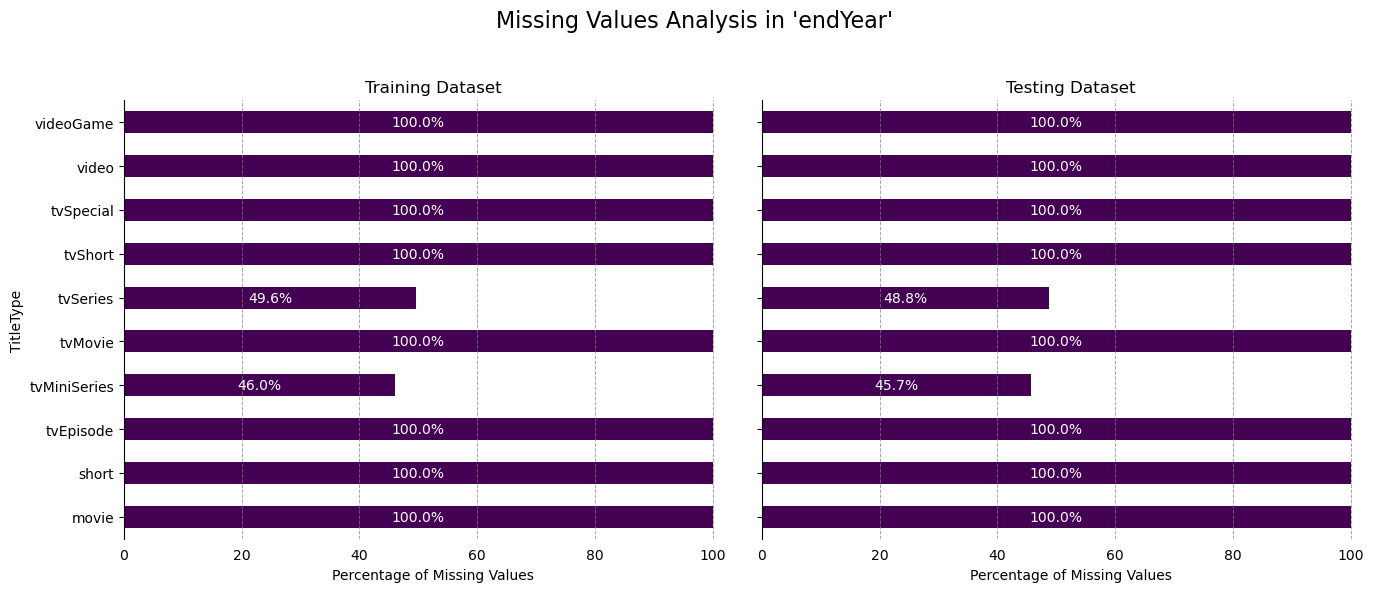

In [124]:
def analyze_missing_years_combined(data_train, data_test, global_title, train_title, test_title):
    """
    Analyze missing values in the 'endYear' column for both training and testing datasets and display
    the percentage of missing values grouped by 'titleType' in a combined plot.

    Args:
        data_train (pd.DataFrame): The training dataset containing 'endYear' and 'titleType' columns.
        data_test (pd.DataFrame): The testing dataset containing 'endYear' and 'titleType' columns.
        global_title (str): The global title for the entire figure.
        train_title (str): The title for the training dataset subplot.
        test_title (str): The title for the testing dataset subplot.
    """
    def plot_individual(ax, data, title):
        """
        Helper function to plot missing values for an individual dataset.
        """
        # Replace '\N' with NaN for proper missing value handling
        data.replace('\\N', np.nan, inplace=True)

        # Calculate the percentage of missing values for each 'titleType'
        grouped_missing = data.groupby('titleType').apply(
            lambda x: x['endYear'].isna().mean() * 100
        )
        grouped_missing = grouped_missing.sort_index()  # Sort by index (alphabetical order)

        # Plot the data
        grouped_missing.plot(kind='barh', ax=ax, colormap='viridis')
        ax.set_title(title)
        ax.set_xlabel('Percentage of Missing Values')
        ax.set_ylabel('TitleType')

        # Add dashed gridlines parallel to the y-axis
        ax.xaxis.set_ticks_position('none')  # Remove ticks from the x-axis
        ax.grid(axis='x', linestyle='--', color='gray', linewidth=0.7, alpha=0.7)

        # Remove the top, right, and bottom spines
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['bottom'].set_visible(False)

        # Add percentage labels to the bars
        for p in ax.patches:
            width = p.get_width()
            if width > 0:  # Only add text if the width is greater than 0
                ax.annotate(f'{width:.1f}%', 
                            (p.get_x() + p.get_width() / 2, p.get_y() + p.get_height() / 2), 
                            ha='center', va='center', fontsize=10, color='white')

    # Create a shared figure for both datasets
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 6), sharey=True)

    # Plot for training data
    plot_individual(axes[0], data_train, train_title)

    # Plot for testing data
    plot_individual(axes[1], data_test, test_title)

    # Add a common title
    fig.suptitle(global_title, fontsize=16)

    # Adjust layout for better visualization
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

# Example usage
analyze_missing_years_combined(
    data_train=data_train,
    data_test=data_test,
    global_title="Missing Values Analysis in 'endYear'",
    train_title="Training Dataset",
    test_title="Testing Dataset"
)



/tmp/ipykernel_14686/1823119046.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped_missing = data.groupby('titleType').apply(


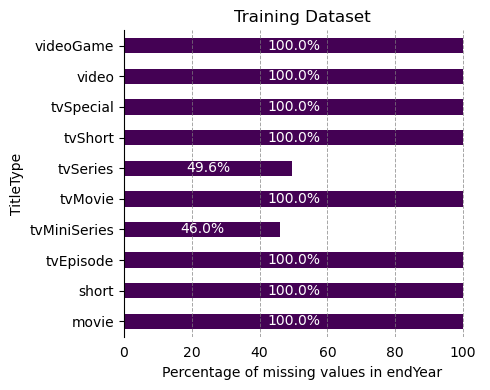

In [125]:
def analyze_missing_values(data, column_name, dataset_title):
    """
    Analyze missing values in a specified column for a dataset and display
    the percentage of missing values grouped by 'titleType'.

    Args:
        data (pd.DataFrame): The dataset containing the specified column and 'titleType'.
        column_name (str): The name of the column to analyze for missing values.
        dataset_title (str): The title for the dataset plot.
    """
    # Replace '\N' with NaN for proper missing value handling
    data.replace('\\N', np.nan, inplace=True)

    # Calculate the percentage of missing values for each 'titleType'
    grouped_missing = data.groupby('titleType').apply(
        lambda x: x[column_name].isna().mean() * 100
    )
    grouped_missing = grouped_missing.sort_index()  # Sort by index (alphabetical order)

    # Create the plot
    fig, ax = plt.subplots(figsize=(5, 4))

    # Plot the data
    grouped_missing.plot(kind='barh', ax=ax, colormap='viridis')
    ax.set_title(dataset_title)
    ax.set_xlabel(f'Percentage of missing values in {column_name}')
    ax.set_ylabel('TitleType')

    # Add dashed gridlines parallel to the y-axis
    ax.xaxis.set_ticks_position('none')  # Remove ticks from the x-axis
    ax.grid(axis='x', linestyle='--', color='gray', linewidth=0.7, alpha=0.7)

    # Remove the top, right, and bottom spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)

    # Add percentage labels to the bars
    for p in ax.patches:
        width = p.get_width()
        if width > 0:  # Only add text if the width is greater than 0
            ax.annotate(f'{width:.1f}%', 
                        (p.get_x() + p.get_width() / 2, p.get_y() + p.get_height() / 2), 
                        ha='center', va='center', fontsize=10, color='white')

    # Adjust layout for better visualization
    plt.tight_layout()
    plt.show()

# Example usage
analyze_missing_values(
    data=data_train,
    column_name='endYear',
    dataset_title="Training Dataset"
)


So the `endYear` is just for `tvMiniSeries` and `tvSeries`. The snippet that follows prints a list of `startYear` if `endYear` is missing ordered and without repetition. For each group print also the cardinality of the set.


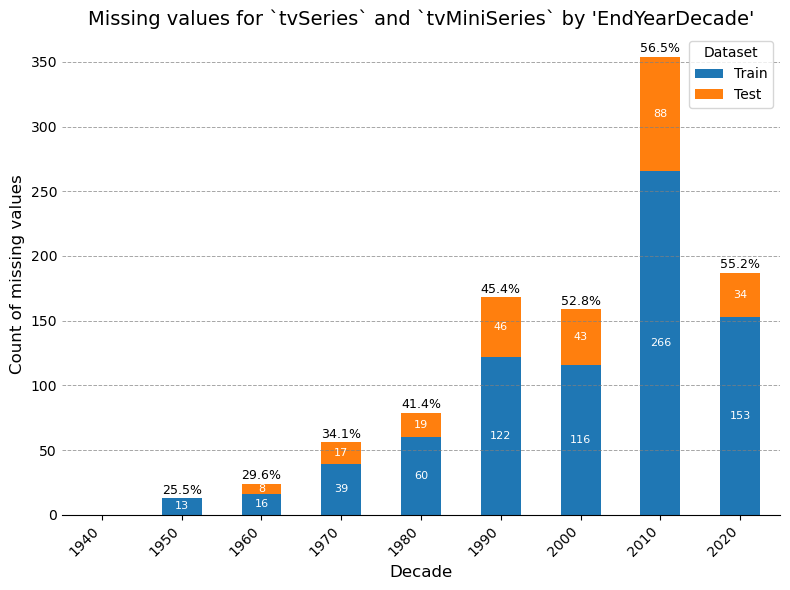

In [126]:
def explore_end_year_behavior_combined(data_train, data_test):
    """
    Combines and visualizes the count of missing 'endYear' values grouped by decade for 'tvSeries' and 'tvMiniSeries'
    in both training and testing datasets. Additionally, calculates the percentage of missing values per decade 
    aggregated across both datasets and displays it above the bars, while showing counts for individual datasets on the bars.

    Args:
        data_train (pd.DataFrame): The training dataset.
        data_test (pd.DataFrame): The testing dataset.
    """
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt

    def process_missing_data(data):
        """
        Processes the data to compute the count of missing 'endYear' values grouped by startYearDecade.
        """
        # Create the startYearDecade column if not already present
        data = data.copy()
        data['startYearDecade'] = (data['startYear'] // 10) * 10

        # Filter only tvSeries and tvMiniSeries
        filtered_data = data[data['titleType'].isin(['tvSeries', 'tvMiniSeries'])]

        # Group by the startYearDecade column
        grouped = filtered_data.groupby('startYearDecade')

        # Count missing endYear values per decade
        missing_count = grouped['endYear'].apply(lambda x: x.isna().sum())
        
        # Count total entries per decade
        total_count = grouped.size()

        return missing_count, total_count

    # Process missing data for both datasets
    missing_train, total_train = process_missing_data(data_train)
    missing_test, total_test = process_missing_data(data_test)

    # Combine the two datasets into a single DataFrame
    combined_missing_df = pd.DataFrame({
        'Train': missing_train,
        'Test': missing_test,
        'Total_Train': total_train,
        'Total_Test': total_test
    }).fillna(0)

    # Calculate aggregated percentages for each decade
    combined_missing_df['Total_Missing'] = combined_missing_df['Train'] + combined_missing_df['Test']
    combined_missing_df['Total_Count'] = combined_missing_df['Total_Train'] + combined_missing_df['Total_Test']
    combined_missing_df['Percentage_Total'] = (combined_missing_df['Total_Missing'] / combined_missing_df['Total_Count']) * 100

    # Plot the combined data
    fig, ax = plt.subplots(figsize=(8, 6))

    # Use the viridis theme for the colormap
    colormap = plt.cm.viridis
    combined_missing_df[['Train', 'Test']].plot(kind='bar', stacked=True, ax=ax)

    # Add counts for Train and Test datasets on the bars
    for idx, (decade, row) in enumerate(combined_missing_df.iterrows()):
        train_height = row['Train']
        test_height = row['Test']

        if train_height > 0:
            ax.text(idx, train_height / 2, f"{int(train_height)}", 
                    ha='center', va='center', color='white', fontsize=8)
        if test_height > 0:
            ax.text(idx, train_height + (test_height / 2), f"{int(test_height)}", 
                    ha='center', va='center', color='white', fontsize=8)

    # Add aggregated percentages above the bars
    for idx, (decade, row) in enumerate(combined_missing_df.iterrows()):
        total_missing = row['Total_Missing']
        percentage_total = row['Percentage_Total']

        if total_missing > 0:
            ax.text(idx, total_missing + 1, f"{percentage_total:.1f}%", 
                    ha='center', va='bottom', fontsize=9, color='black')

    # Customization
    ax.set_title("Missing values for `tvSeries` and `tvMiniSeries` by 'EndYearDecade'", fontsize=14)
    ax.set_xlabel("Decade", fontsize=12)
    ax.set_ylabel("Count of missing values", fontsize=12)
    ax.legend(title="Dataset", labels=['Train', 'Test'])
    ax.grid(axis='y', linestyle='--', color='gray', linewidth=0.7, alpha=0.7)

    # Update x-axis labels for decade ranges
    ax.set_xticks(range(len(combined_missing_df.index)))
    ax.set_xticklabels(combined_missing_df.index, rotation=45, ha='right', fontsize=10)

    # Remove the top, left, and right borders
    ax.spines['top'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Optionally, add horizontal ticks only
    ax.yaxis.tick_left()
    ax.tick_params(axis='y', length=0)  # Remove ticks from the y-axis for cleaner visuals

    plt.tight_layout()
    plt.show()

# Example usage
explore_end_year_behavior_combined(data_train, data_test)

There is no clear behaviour for missing values.

It can be assumed that increasng number for most recent year is due the fact that some tvSeries or tvMiniSeries are not finished, but we can't be sure, so we just decided to remove the column.

# runTimeMinutes
Let's check the percentage of missing values (`\N`) and then, as we did for `startYear` and `endYear` we plot it for cathegories. 

/tmp/ipykernel_14686/1823119046.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped_missing = data.groupby('titleType').apply(


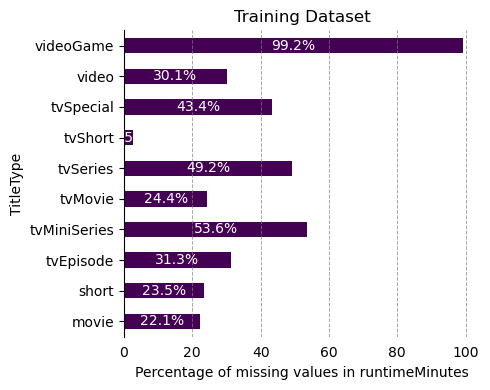

In [127]:
def analyze_missing_values_combined(data_train, data_test, column_to_analyze, group_by_column, global_title, train_title, test_title):
    """
    Analyze missing values ('\\N') in a specific column for both training and testing datasets
    and display the percentage of missing values grouped by another column in a combined plot.

    Args:
        data_train (pd.DataFrame): The training dataset.
        data_test (pd.DataFrame): The testing dataset.
        column_to_analyze (str): The column to analyze for missing values.
        group_by_column (str): The column to group by when calculating missing values.
        global_title (str): The global title for the entire figure.
        train_title (str): The title for the training dataset subplot.
        test_title (str): The title for the testing dataset subplot.
    """
    def process_and_plot(ax, data, title):
        """
        Helper function to process data and plot missing value analysis for a single dataset.
        """
        # Replace '\\N' with NaN for proper missing value handling
        data.replace('\\N', np.nan, inplace=True)

        # Ensure the columns exist in the dataset
        if column_to_analyze not in data.columns:
            raise ValueError(f"Column '{column_to_analyze}' not found in the dataset.")
        if group_by_column not in data.columns:
            raise ValueError(f"Group-by column '{group_by_column}' not found in the dataset.")

        # Calculate the percentage of missing values for the specified column grouped by the group_by_column
        grouped_missing = data.groupby(group_by_column).apply(
            lambda x: x[column_to_analyze].isna().mean() * 100
        )
        grouped_missing = grouped_missing.sort_index()

        # Plot the data
        grouped_missing.plot(kind='barh', ax=ax, colormap="viridis")
        ax.set_title(title)
        ax.set_xlabel('Percentage of Missing Values')
        ax.set_ylabel(group_by_column)

        # Add dashed gridlines parallel to the x-axis
        ax.xaxis.set_ticks_position('none')  # Remove ticks from the x-axis
        ax.grid(axis='x', linestyle='--', color='gray', linewidth=0.7, alpha=0.7)

        # Remove spines: keep the left spine, remove the bottom, top, and right spines
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['bottom'].set_visible(False)
        ax.spines['left'].set_visible(True)

        # Add percentage labels to the bars
        for p in ax.patches:
            if p.get_width() > 0:  # Only annotate non-zero bars
                ax.annotate(f'{p.get_width():.1f}%', 
                            (p.get_width(), p.get_y() + p.get_height() / 2.), 
                            ha='left', va='center', fontsize=8, color='black', xytext=(5, 0),
                            textcoords='offset points')

    # Create a shared figure for both datasets
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 6), sharey=True)

    # Plot for training data
    process_and_plot(axes[0], data_train, train_title)

    # Plot for testing data
    process_and_plot(axes[1], data_test, test_title)

    # Add a common title
    fig.suptitle(global_title, fontsize=16)

    # Adjust layout for better visualization
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

analyze_missing_values(
    data=data_train,
    column_name='runtimeMinutes',
    dataset_title="Training Dataset"
)




## Drop `videoGame`
Due the fact that videoGame is a cathegory which is different from all the other and has a lot of missing value we drop it also because his cardinality is low.


In [128]:
# Drop rows where titleType is 'videoGame'
data_train = data_train[data_train['titleType'] != 'videoGame']
data_test = data_test[data_test['titleType'] != 'videoGame']

print("Rows with 'videoGame' titleType dropped successfully.")

Rows with 'videoGame' titleType dropped successfully.


# awardWins
As before we check for missing values

/tmp/ipykernel_14686/684804227.py:29: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped_missing = data.groupby(group_by_column).apply(
/tmp/ipykernel_14686/684804227.py:29: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped_missing = data.groupby(group_by_column).apply(


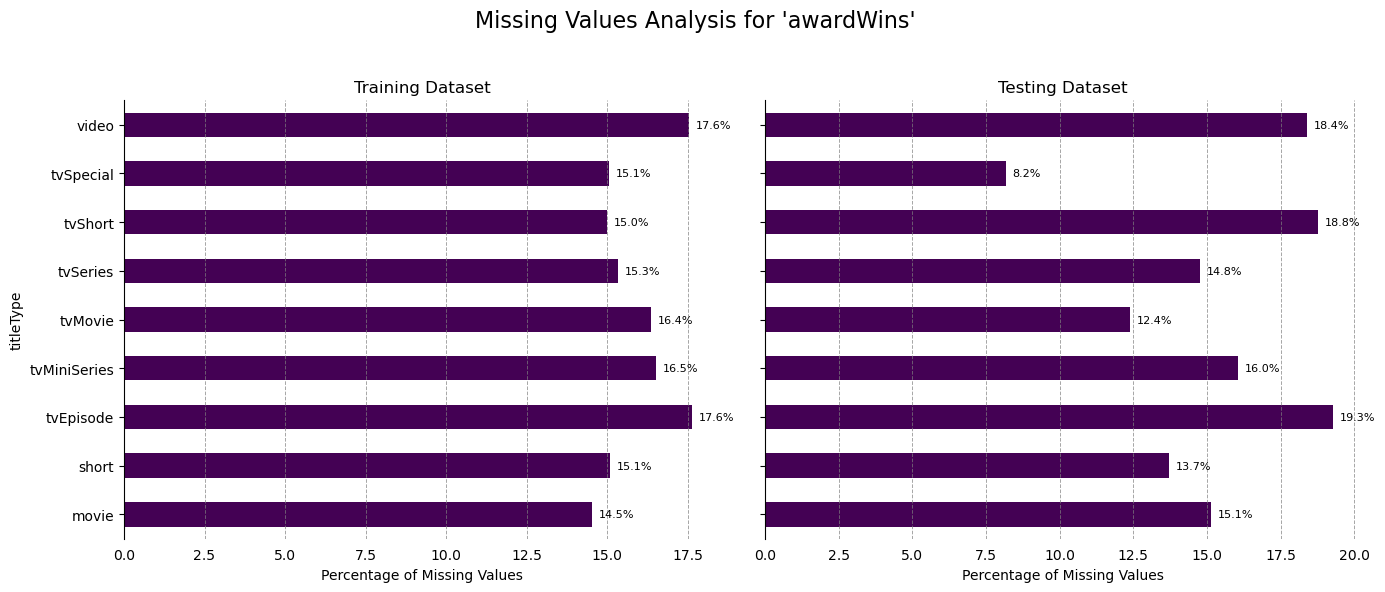

In [129]:
analyze_missing_values_combined(
    data_train=data_train,
    data_test=data_test,
    column_to_analyze='awardWins',
    group_by_column='titleType',
    global_title="Missing Values Analysis for 'awardWins'",
    train_title="Training Dataset",
    test_title="Testing Dataset"
)

In [130]:
# print aggregate median of awardWins by titleType
print(data_train.groupby('titleType')['awardWins'].median())
print(data_test.groupby('titleType')['awardWins'].median())

titleType
movie           0.0
short           0.0
tvEpisode       0.0
tvMiniSeries    0.0
tvMovie         0.0
tvSeries        0.0
tvShort         0.0
tvSpecial       0.0
video           0.0
Name: awardWins, dtype: float64
titleType
movie           0.0
short           0.0
tvEpisode       0.0
tvMiniSeries    0.0
tvMovie         0.0
tvSeries        0.0
tvShort         0.0
tvSpecial       0.0
video           0.0
Name: awardWins, dtype: float64


In this case we check for each group the median of `awardWins`

In [131]:

def print_group_median(data, column_to_analyze, group_by_column):
    """
    Print the median of a specific column grouped by another column.

    Args:
        data (pd.DataFrame): The input dataset containing various columns.
        column_to_analyze (str): The column to calculate the median for.
        group_by_column (str): The column to group by when calculating the median.
    """
    # Ensure the columns exist in the dataset
    if column_to_analyze not in data.columns:
        raise ValueError(f"Column '{column_to_analyze}' not found in the dataset.")
    if group_by_column not in data.columns:
        raise ValueError(f"Group-by column '{group_by_column}' not found in the dataset.")

    # Convert the column to analyze to numeric (if not already)
    data[column_to_analyze] = pd.to_numeric(data[column_to_analyze], errors='coerce')

    # Calculate the median grouped by the group_by_column
    grouped_median = data.groupby(group_by_column)[column_to_analyze].median()

    # Print the results
    print(f"Median values of '{column_to_analyze}' grouped by '{group_by_column}':")
    print(grouped_median)

print_group_median(data_train, 'awardWins', 'titleType')
print_group_median(data_test, 'awardWins', 'titleType')


Median values of 'awardWins' grouped by 'titleType':
titleType
movie           0.0
short           0.0
tvEpisode       0.0
tvMiniSeries    0.0
tvMovie         0.0
tvSeries        0.0
tvShort         0.0
tvSpecial       0.0
video           0.0
Name: awardWins, dtype: float64
Median values of 'awardWins' grouped by 'titleType':
titleType
movie           0.0
short           0.0
tvEpisode       0.0
tvMiniSeries    0.0
tvMovie         0.0
tvSeries        0.0
tvShort         0.0
tvSpecial       0.0
video           0.0
Name: awardWins, dtype: float64


In [132]:
def fill_missing_values_with_median(data, column_to_fill, group_by_column):
    """
    Fill missing values in a specified column with the median value of the column grouped by another column.

    Args:
        data (pd.DataFrame): The input dataset containing the column to fill and the group-by column.
        column_to_fill (str): The column in which to fill missing values.
        group_by_column (str): The column to group by when calculating the median.

    Returns:
        pd.DataFrame: A DataFrame with missing values in the specified column filled.
    """
    # Ensure the columns exist in the dataset
    if column_to_fill not in data.columns:
        raise ValueError(f"Column '{column_to_fill}' not found in the dataset.")
    if group_by_column not in data.columns:
        raise ValueError(f"Group-by column '{group_by_column}' not found in the dataset.")

    # Replace '\N' with NaN for proper handling of missing values
    data[column_to_fill] = pd.to_numeric(data[column_to_fill], errors='coerce')  # Ensure numeric type
    data[group_by_column] = data[group_by_column].astype(str)  # Ensure the group-by column is a string

    # Fill missing values with the median of the group
    data[column_to_fill] = data.groupby(group_by_column)[column_to_fill].transform(
        lambda x: x.fillna(x.median())
    )

    return data

# Example usage
data_train = fill_missing_values_with_median(data_train, 'awardWins', 'titleType')
data_test = fill_missing_values_with_median(data_test, 'awardWins', 'titleType')
print("Missing values of `awardWins` filled successfully.")

Missing values of `awardWins` filled successfully.


# `worstRating` and `bestRating`
These are dummy columns, we just drop them

In [133]:
data_test.drop('worstRating', axis=1, inplace=True)
data_train.drop('worstRating', axis=1, inplace=True)

data_test.drop('bestRating', axis=1, inplace=True)
data_train.drop('bestRating', axis=1, inplace=True)

# `titleType`
Plot the number of element in the dataset groupedBy title type and plot the percentage of missing values in another plot always groupedBy title and only of this column

/tmp/ipykernel_14686/4008497395.py:32: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  viridis = cm.get_cmap('viridis', 4)  # Get 4 colors from the viridis colormap


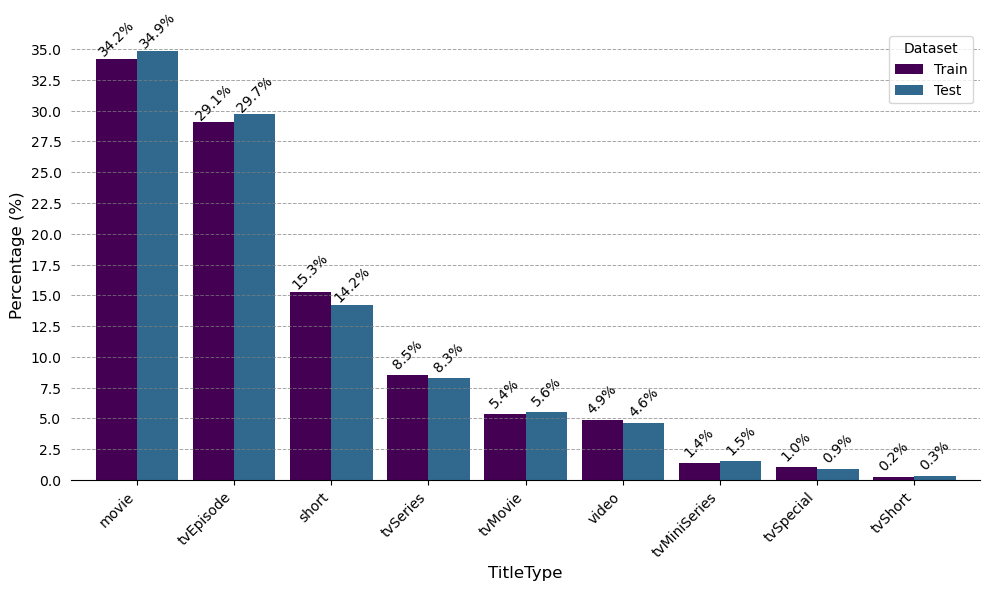

In [134]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

def plot_title_type_analysis_combined(data_train, data_test):
    """
    Plot the percentage of elements in the training and testing datasets grouped by title type in a single bar chart.
    The bars are sorted by the cardinality of the groups (total count).

    Args:
        data_train (pd.DataFrame): The training dataset containing a 'titleType' column.
        data_test (pd.DataFrame): The testing dataset containing a 'titleType' column.
    """
    
    # Ensure the 'titleType' column exists in both datasets
    if 'titleType' not in data_train.columns or 'titleType' not in data_test.columns:
        raise ValueError("Column 'titleType' not found in one or both datasets.")

    # Count the number of elements grouped by title type for both datasets
    train_counts = data_train['titleType'].value_counts(normalize=True) * 100
    test_counts = data_test['titleType'].value_counts(normalize=True) * 100

    # Combine the counts into a single DataFrame
    combined_counts = pd.DataFrame({'Train': train_counts, 'Test': test_counts}).fillna(0)

    # Add a 'Total' column to sort by total cardinality
    combined_counts['Total'] = combined_counts['Train'] + combined_counts['Test']
    combined_counts = combined_counts.sort_values(by='Total', ascending=False).drop(columns=['Total'])

    # Define the colors from the viridis colormap
    viridis = cm.get_cmap('viridis', 4)  # Get 4 colors from the viridis colormap
    colors = [viridis(0), viridis(1)]  # Select color 0 and color 2

    # Plot the data
    ax = combined_counts.plot(kind='bar', figsize=(10, 6), color=colors, width=0.85)

    # Add labels and title
    # plt.title('Percentage of elements grouped by `titleType` (train vs test)', fontsize=16)
    plt.ylabel('Percentage (%)', fontsize=12)
    plt.xlabel('TitleType', fontsize=12)
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.legend(title="Dataset", fontsize=10)

    # Add percentages above the bars, rotated by 45 degrees and slightly higher
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.1f}%', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', 
                    xytext=(0, 15),  # Adjusted from 10 to 15 to raise the text
                    textcoords='offset points', 
                    fontsize=10, color='black', rotation=45)

    # Add gridlines parallel to the y-axis every 2.5 units
    ax.yaxis.set_ticks_position('none')  # Remove ticks from the y-axis
    ax.yaxis.set_major_locator(plt.MultipleLocator(2.5))
    ax.grid(axis='y', linestyle='--', color='gray', linewidth=0.7, alpha=0.7)

    # Remove spines for a clean look
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)  # Remove the left spine

    plt.tight_layout()
    plt.show()

# Example usage
plot_title_type_analysis_combined(data_train, data_test)

In [135]:
# remove from data_train and data_test all records with titleType 'tvMiniSeries', 'tvSpecial' and 'tvShort'

data_train = data_train[~data_train['titleType'].isin(['tvMiniSeries', 'tvSpecial', 'tvShort'])]

data_test = data_test[~data_test['titleType'].isin(['tvMiniSeries', 'tvSpecial', 'tvShort'])]

print("Rows with 'tvMiniSeries', 'tvSpecial', and 'tvShort' titleType dropped successfully.")

Rows with 'tvMiniSeries', 'tvSpecial', and 'tvShort' titleType dropped successfully.


/tmp/ipykernel_14686/4008497395.py:32: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  viridis = cm.get_cmap('viridis', 4)  # Get 4 colors from the viridis colormap


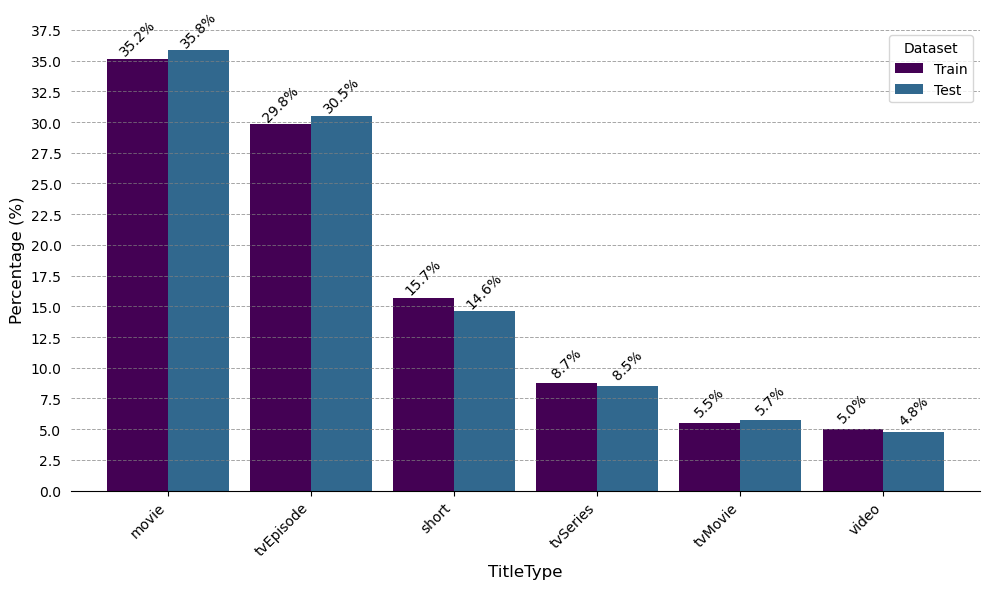

In [136]:
plot_title_type_analysis_combined(data_train, data_test)

/tmp/ipykernel_14686/3161133526.py:32: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped_missing = data.groupby('titleType', group_keys=False).apply(
/tmp/ipykernel_14686/3161133526.py:42: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = plt.cm.get_cmap('viridis', len(grouped_missing.index.get_level_values(0).unique()))
/tmp/ipykernel_14686/3161133526.py:32: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping c

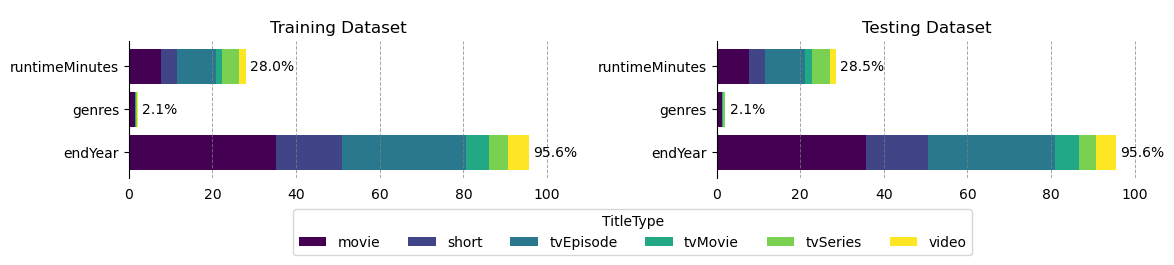

In [137]:
# Crea copie dei dataset senza la colonna 'awardWins'
data_train_no_awardWins = data_train.drop(columns=['awardWins'])
data_test_no_awardWins = data_test.drop(columns=['awardWins'])

# Esempio di utilizzo
plot_missing_values_by_title_type_combined(
    data_train=data_train_no_awardWins,
    data_test=data_test_no_awardWins,
    global_title="",
    train_title="Training Dataset",
    test_title="Testing Dataset"
)

In [138]:
data_test.drop('endYear', axis=1, inplace=True)
data_train.drop('endYear', axis=1, inplace=True)

#### `isRatable`, `canHaveEpisodes` and `isAdult`

- `isRatable` is just removed
- `canHaveEpisode` is mantained
- `isAdult` cast to bool


In [139]:
# Remove `isRatable` column
if 'isRatable' in data_train.columns:
    data_train.drop(columns='isRatable', inplace=True)
if 'isRatable' in data_test.columns:
    data_test.drop(columns='isRatable', inplace=True)

print("Columns refactored successfully.")

Columns refactored successfully.


# `titleType` analysis

1. **Print All Possible Values of `titleType`:**  
   Extract and display all unique values present in the `titleType` column to understand its categories.

2. **Print All Unique Pairs `{titleType, canHaveEpisodes}`:**  
   Display all distinct combinations of `titleType` and `canHaveEpisodes` from the dataset to analyze their relationships.

In [140]:
def analyze_title_types(data):
    # Get and sort unique values of `titleType`
    unique_title_types = sorted(data['titleType'].unique())
    print(unique_title_types)

    # Get and sort unique pairs {titleType, canHaveEpisodes}
    unique_pairs = data[['titleType', 'canHaveEpisodes']].drop_duplicates()
    unique_pairs = unique_pairs.sort_values(by=['titleType', 'canHaveEpisodes'])
    print(unique_pairs)

    return unique_title_types, unique_pairs

# data_train
analyze_title_types(data_train)
analyze_title_types(data_test)

['movie', 'short', 'tvEpisode', 'tvMovie', 'tvSeries', 'video']
    titleType  canHaveEpisodes
2       movie            False
8       short            False
0   tvEpisode            False
10    tvMovie            False
3    tvSeries             True
5       video            False
['movie', 'short', 'tvEpisode', 'tvMovie', 'tvSeries', 'video']
    titleType  canHaveEpisodes
1       movie            False
9       short            False
3   tvEpisode            False
14    tvMovie            False
6    tvSeries             True
0       video            False


(['movie', 'short', 'tvEpisode', 'tvMovie', 'tvSeries', 'video'],
     titleType  canHaveEpisodes
 1       movie            False
 9       short            False
 3   tvEpisode            False
 14    tvMovie            False
 6    tvSeries             True
 0       video            False)

There is a correlation between `titleType` and `canHaveEpisodes`. The `canHaveEpisodes` column might be redundant.

In [141]:
# Remove `canHaveEpisodes` column
if 'canHaveEpisodes' in data_train.columns:
    data_train.drop(columns='canHaveEpisodes', inplace=True)
if 'canHaveEpisodes' in data_test.columns:
    data_test.drop(columns='canHaveEpisodes', inplace=True)

# New column `totalRecognitions`
1. `Nominations = Award wins + AwardNominations excluded wins` if there is a missing value in one of the original columns, then the values is set to `-1`


In [142]:
def add_nominations_column(data):
    """
    Add a new column `totalRecognitions` computed as:
    Nominations = awardWins + awardNominationsExcludeWins.
    If either value is missing, set `totalRecognitions` to -1.
    
    Parameters:
    - data (pd.DataFrame): The input dataset.
    
    Returns:
    - pd.DataFrame: The updated dataset with the new `totalRecognitions` column.
    """
    
    # Calculate the `totalRecognitions` column
    data['totalRecognitions'] = data.apply(
        lambda row: np.nan if row['awardWins'] == -1 or row['awardNominationsExcludeWins'] == -1 
        else row['awardWins'] + row['awardNominationsExcludeWins'], 
        axis=1
    )
    
    return data

data_test = add_nominations_column(data_test)
data_train = add_nominations_column(data_train)

# `originalTitle`
`clean_strings` processes a column by converting it to a lowercase string, removing special characters, and handling lists by concatenating their items into a single string. It ensures that the input is always a string and cleans it to retain only alphanumeric characters and spaces.

This function is applied to the `originalTitle` column of both training (`data_train`) and test (`data_test`) datasets, standardizing the titles for further analysis.

In [143]:
# import re  # Libreria per espressioni regolari

# def normalize_original_title(title):
#     """
#     Normalizza la stringa della colonna 'originalTitle'.
    
#     - Concatena liste separate da virgole in un'unica stringa.
#     - Rimuove caratteri speciali, mantenendo solo lettere e spazi.
#     - Converte tutto in lowercase.
    
#     Args:
#         title (str): Stringa della colonna 'originalTitle'.
    
#     Returns:
#         str: Stringa normalizzata.
#     """
#     # 1. Se la stringa è una lista (separata da virgole), uniscila in una singola stringa
#     if isinstance(title, list):
#         title = ', '.join(title)
    
#     # 2. Rimuovi caratteri speciali, mantenendo solo lettere e spazi
#     title = re.sub(r'[^a-zA-Z\s]', '', title)
    
#     # 3. Converte tutto in lowercase
#     title = title.lower()
    
#     # 4. Rimuovi spazi multipli e spazi iniziali/finali
#     title = re.sub(r'\s+', ' ', title).strip()
    
#     return title

# data_train['originalTitle'] = data_train['originalTitle'].apply(normalize_original_title)
# data_test['originalTitle'] = data_test['originalTitle'].apply(normalize_original_title)

# one-hot encoding
This Python code defines a function `process_column` to preprocess a column of a DataFrame by cleaning its values, performing one-hot encoding, and saving metadata about the newly generated columns.

#### Steps in the Function:
1. **Clean the Column**:
   - Ensures the column values are strings.
   - Strips unwanted characters (`[]` and `'`) and splits values into a list.

2. **Add a Count Column**:
   - Creates a new column named dynamically as `NumberOf<ColumnName>`.
   - Stores the count of items in the list for each row.

3. **One-Hot Encoding**:
   - Transforms the column into a one-hot encoded DataFrame by expanding the lists into separate binary columns.

4. **Combine Data**:
   - Merges the one-hot encoded columns back with the original DataFrame.

5. **Save Metadata**:
   - Writes the names of the newly created columns (count column and one-hot encoded columns) to a specified file.

6. **Remove Original Column**:
   - Drops the original column from the DataFrame.

#### `merge_txt_files`
The `merge_txt_files` function merges multiple `.txt` files into a single output file, ensuring no duplicate lines. It reads lines from input files into a set (to remove duplicates), sorts them alphabetically, and writes the result to the specified output file.

- **Removes Duplicates**: Ensures unique lines in the output.
- **Alphabetical Sorting**: Orders lines for consistency.
- **Flexible Input**: Accepts a variable number of input files.


In [144]:
import numpy as np
import pandas as pd

def one_hot_encoding(data, column_name, columns_file, missing_value_replacement="unknown"):
    """
    Performs one-hot encoding on a specified column of a DataFrame.

    Args:
        data (pd.DataFrame): Input DataFrame.
        column_name (str): Column to be one-hot encoded.
        columns_file (str): File to save the new column names.
        missing_value_replacement (str): String to replace missing values with.

    Returns:
        pd.DataFrame: Updated DataFrame with one-hot encoded columns.
    """
    # Replace missing values in the column with the specified string
    data[column_name] = data[column_name].fillna(missing_value_replacement)
    
    # Ensure the column values are strings
    data[column_name] = data[column_name].astype(str)
    
    # Debugging: print unique values after handling missing values
    print(f"Unique values in {column_name} after handling missing values: {data[column_name].unique()}")

    # Split the string into lists of items (if applicable)
    data[column_name] = data[column_name].apply(lambda x: 
        [item.strip() for item in x.strip("[]").replace("'", "").split(",")] if isinstance(x, str) else [])

    # Debugging: print the first few rows of the processed column
    print(f"Processed {column_name}:")
    print(data[column_name].head())

    # Create a new column that counts the number of items in the list
    number_column_name = f"NumberOf{column_name.capitalize()}"
    data[number_column_name] = data[column_name].apply(len)

    # Perform one-hot encoding
    one_hot = pd.get_dummies(data[column_name].apply(pd.Series).stack()).groupby(level=0).sum()

    # Debugging: print the generated one-hot encoded columns
    print(f"Generated one-hot columns:")
    print(one_hot.head())

    # Concatenate the one-hot encoded columns with the original dataset
    data = pd.concat([data, one_hot], axis=1)

    # Save the names of the one-hot encoded columns to a file
    new_columns = list(one_hot.columns)
    with open(columns_file, 'w') as f:
        for column in new_columns:
            f.write(f"{column}\n")

    # Drop the original column
    data.drop(columns=[column_name], inplace=True)

    return data



def merge_txt_files(output_file, *input_files):
    merged_lines = set()
    for file in input_files:
        with open(file, 'r') as f:
            lines = f.read().splitlines()
            for line in lines:
                merged_lines.add(line.strip())
    
    with open(output_file, 'w') as f:
        for line in sorted(merged_lines):
            f.write(f"{line}\n")

## One-hot encoding: `countryOfOrigin`

In [145]:
data_train = one_hot_encoding(data_train, 'countryOfOrigin', columns_file='encoding_lists/countryOfOrigin_train.txt')
data_test = one_hot_encoding(data_test, 'countryOfOrigin', columns_file='encoding_lists/countryOfOrigin_test.txt')

merge_txt_files('encoding_lists/countryOfOrigin.txt', 'encoding_lists/countryOfOrigin_train.txt', 'encoding_lists/countryOfOrigin_test.txt')

Unique values in countryOfOrigin after handling missing values: ["['US']" "['RU']" "['MX']" "['KR']" "['BR']" "['SUHH']"
 "['FR', 'MK', 'SI']" "['IN']" "['JP']" "['PL']" "['FR']" "['GB']"
 "['DDDE']" "['GR']" "['NP']" "['NO']" "['DE']" "['SE']" "['CZ', 'SK']"
 "['FI']" "['AU']" "['BE']" "['CY', 'DE']" "['IT', 'FR']" "['CA', 'US']"
 "['LT']" "['NZ']" "['CA']" "['IT']" "['HK', 'CN']" "['ES']" "['IR']"
 "['GB', 'US']" "['AZ']" "['RO']" "['DK']" "['TR']" "['XWG']"
 "['FR', 'XWG']" "['HR']" "['EG']" "['CN', 'TW']" "['CO']" "['CSHH']"
 "['GB', 'GP']" "['AR']" "['US', 'GB']" "['AR', 'BR', 'CL']" "['VN']"
 "['TH']" "['IT', 'FR', 'XWG', 'ES']" "['GR', 'US']" "['CA', 'GB']"
 "['AE']" "['VE']" "['PH']" "['AT']" "['FR', 'IL']" "['NL']" "['CN']"
 "['GB', 'MX']" "['CSHH', 'DE']" "['US', 'IN']" "['ID']" "['CL']"
 "['GB', 'NL']" "['SE', 'DK']" "['ES', 'MX']" "['HU']" "['AL']"
 "['LU', 'BE', 'AT']" "['ES', 'DE']" "['US', 'CA']" "['FR', 'CA']"
 "['CH']" "['SG']" "['PL', 'BE']" "['IT', 'FR', 'XWG']"
 "['

## One-hot encoding: `genres`

Before to one-hot encode genres we just drop unknown columns ('\N')

In [146]:
data_train = one_hot_encoding(data_train, 'genres', columns_file='encoding_lists/genres_train.txt')
data_test = one_hot_encoding(data_test, 'genres', columns_file='encoding_lists/genres_test.txt')

merge_txt_files('encoding_lists/genres.txt', 'encoding_lists/genres_train.txt', 'encoding_lists/genres_test.txt')


Unique values in genres after handling missing values: ['Action,Adventure,Animation' 'Comedy' 'Reality-TV' 'Comedy,Drama,Romance'
 'Documentary,Short' 'Drama,Romance' 'Animation,Short' 'Action' 'Family'
 'Comedy,Romance' 'Drama' 'Short' 'Comedy,Short' 'Crime,Drama,Mystery'
 'Drama,Western' 'Crime' 'Drama,History,War' 'Western' 'Drama,Mystery'
 'unknown' 'Crime,Drama,Romance' 'Crime,Drama' 'Adult,Short'
 'Family,Game-Show' 'Talk-Show' 'Adventure,Comedy,Short' 'Action,Crime'
 'Action,Adventure,Crime' 'Comedy,Family' 'Game-Show' 'Crime,Thriller'
 'Adult' 'Drama,Sci-Fi,Thriller' 'Documentary' 'Drama,Thriller'
 'Drama,Short' 'Reality-TV,Romance' 'Action,Adventure,Family'
 'Fantasy,Horror,Short' 'Family,Music' 'Drama,Fantasy'
 'Comedy,Drama,Mystery' 'Adventure,Animation,Comedy' 'Comedy,Reality-TV'
 'Family,Fantasy,Music' 'Comedy,Drama,Thriller' 'Comedy,Drama,Short'
 'Horror,Thriller' 'Action,Short' 'Adventure,Documentary'
 'Animation,Family' 'Comedy,Talk-Show' 'Thriller' 'Comedy,Romance,Shor

In [147]:
# titleType label encoding
titleType_encoding = {
    'tvSeries': 0,
    'movie': 1,
    'tvEpisode': 2,
    'tvMovie': 3,
    'tvSpecial': 4,
    'tvMiniSeries': 5,
    'tvShort': 6,
    'video': 7,
    'short': 8
}

data_train['titleType'] = data_train['titleType'].map(titleType_encoding)
data_test['titleType'] = data_test['titleType'].map(titleType_encoding)

# Save the encoding dictionary to a txt file
with open('encoding_lists/titleType.txt', 'w') as f:
    for key, value in titleType_encoding.items():
        f.write(f"{key}: {value}\n")

# `title` analysis
Analyzing by eyes the dataset we saw a lot of titles with `episode` or something similar, so we decided to analyze them a little bit to explore their caratheristics.

1. Check most freqent $k$-grams ($k=4$ and $k=5$)
2. Print them


In [148]:
from collections import Counter

def analyze_k_grams(data, column_name='title', k=4, top_n=5):
    """
    Analizza i k-grams in una colonna specificata di un DataFrame.

    Args:
        data (pd.DataFrame): Il DataFrame contenente i dati.
        column_name (str): La colonna da analizzare.
        k (int): La lunghezza dei k-grams.
        top_n (int): Il numero di k-grams più frequenti da stampare.

    Returns:
        Counter: Un oggetto Counter contenente le frequenze dei k-grams.
    """
    # Generate k-grams
    k_grams = []
    for title in data[column_name]:
        k_grams.extend(title[i:i + k] for i in range(len(title) - k + 1))
    
    # Count k-grams frequencies
    k_grams_counter = Counter(k_grams)
    
    # Print the top_n k-grams
    print(f"Top {top_n} {k}-grams:")
    for k_gram, count in k_grams_counter.most_common(top_n):
        print(f"{k_gram}: {count}")

#### K-grams `data_train`, k=5

In [149]:
analyze_k_grams(data_train, column_name='originalTitle', k=5)
analyze_k_grams(data_test, column_name='originalTitle', k=5)

Top 5 5-grams:
 the : 1052
pisod: 517
isode: 515
Episo: 512
sode : 511
Top 5 5-grams:
 the : 382
isode: 172
pisod: 171
sode : 170
Episo: 166


#### K-grams `data_train`, k=6

In [150]:
analyze_k_grams(data_train, column_name='originalTitle', k=6)
analyze_k_grams(data_test, column_name='originalTitle', k=6)


Top 5 6-grams:
pisode: 515
Episod: 512
isode : 511
sode #: 466
ode #1: 306
Top 5 6-grams:
pisode: 170
isode : 170
Episod: 166
sode #: 150
ode #1: 92


#### Analysis of the results
The $k$-gram `pisod` seems to be the best one to choose in order to analyze titles.

It manages properly words like `episode` and `episodio`.

The following python function filters only rows with a $5-gram$ `pisod` and then print for that rows the `titleType`.

In [151]:
def filter_titles_with_k_gram(data, k_gram='pisod', column_name='title', print_column='titleType'):
    """
    Filters rows containing the specified k-gram and prints the values of a specified column.

    Parameters:
    - data (pd.DataFrame): The input dataset.
    - k_gram (str): The k-gram to filter for (default: 'pisod').
    - column_name (str): The column to search for the k-gram (default: 'title').
    - print_column (str): The column to display for filtered rows (default: 'titleType').

    Returns:
    - pd.DataFrame: A DataFrame containing only the rows with the specified k-gram.
    """
    # Ensure the specified columns exist in the DataFrame
    if column_name not in data.columns or print_column not in data.columns:
        raise ValueError(f"Column '{column_name}' or '{print_column}' not found in the dataset.")
    
    # Filter rows containing the k-gram
    filtered_data = data[data[column_name].str.contains(k_gram, case=False, na=False)]
    
    # Print the values of the specified column for filtered rows
    print(f"Values in '{print_column}' for rows containing '{k_gram}':")
    print(filtered_data[print_column].value_counts())
    
    return filtered_data

# Example usage:
# Assuming `data` is your DataFrame
filtered_train = filter_titles_with_k_gram(data_train, k_gram='pisod', column_name='originalTitle', print_column='titleType')
filtered_test  = filter_titles_with_k_gram(data_test, k_gram='pisod', column_name='originalTitle', print_column='titleType')


Values in 'titleType' for rows containing 'pisod':
titleType
2    516
7      1
Name: count, dtype: int64
Values in 'titleType' for rows containing 'pisod':
titleType
2    170
8      1
Name: count, dtype: int64


It seems like there is no issues with this originalTitle.

In order to be sure about that we count all tvEpisode and show what's the difference in cardinality if we remove these entries or not.

# `totalImages` and `totalVideos`
Merge them in `totaMedia = totalImages + totalVideos` and drop the two original columns

In [152]:
# Merge `totalImages` and `totalVideos` into `totalMedia`
data_train['totalMedia'] = data_train['totalImages'] + data_train['totalVideos']
data_test['totalMedia'] = data_test['totalImages'] + data_test['totalVideos']

print("Columns merged successfully.")

Columns merged successfully.


In [153]:
# print unique couples of isAdult and Adult and the number of occurrences of each couple
def analyze_isAdult(data):
    """
    Analyze the 'isAdult' and 'Adult' columns in the dataset.

    Parameters:
    - data (pd.DataFrame): The input dataset.

    Returns:
    - pd.Series: The value counts of unique combinations of 'isAdult' and 'Adult'.
    """
    # Ensure the columns exist in the DataFrame
    if 'isAdult' not in data.columns or 'Adult' not in data.columns:
        raise ValueError("Columns 'isAdult' and 'Adult' not found in the dataset.")
    
    # Count the occurrences of unique combinations of 'isAdult' and 'Adult'
    isAdult_counts = data.groupby(['isAdult', 'Adult']).size()
    
    print("Unique combinations of 'isAdult' and 'Adult' and their counts:")
    print(isAdult_counts)
    # print a bit more structured informations
    print("\n")
    print("Detailed information:")
    print(data.groupby(['isAdult', 'Adult']).size().reset_index(name='Count'))


analyze_isAdult(data_train)

Unique combinations of 'isAdult' and 'Adult' and their counts:
isAdult  Adult
0        0        15323
1        0           15
         1          404
dtype: int64


Detailed information:
   isAdult  Adult  Count
0        0      0  15323
1        1      0     15
2        1      1    404


In [154]:
def store_dataset(data, filename):
    
    file_path = f"{filename}.csv"
    data.to_csv(file_path, index=False)
    
    print(f"Dataset successfully stored as {file_path}")
    return file_path

output_train = store_dataset(data_train, 'data/output/00_data_understanding/data_train')
output_test  = store_dataset(data_test, 'data/output/00_data_understanding/data_test')

Dataset successfully stored as data/output/00_data_understanding/data_train.csv
Dataset successfully stored as data/output/00_data_understanding/data_test.csv
